## EDA Notebook

Readmission risk can be understood across four dimensions: who the patient is biologically, how complex their condition is, how severe this specific admission was, and what their history of care looks like. The EDA is organized around these dimensions rather than individual features, using clinical reasoning to guide which columns are worth investigating and why.

The first examines glycemic control through HbA1c results, investigating whether poor long-term glucose management correlates with higher readmission rates. Given the high missingness in this column, the analysis also explores whether the absence of an A1C test itself carries signal.

The second investigates clinical severity through primary and secondary diagnoses. Does having more than one diagnosis increase readmission risk? Do diagnoses with known high comorbidity rates with diabetes, such as cardiac and renal conditions, show stronger associations than unrelated diagnoses?

The third thread examines treatment complexity. Do medication changes during the admission indicate better or worse outcomes? Are patients not on any diabetes medications at higher readmission risk, suggesting unmanaged disease?

The fourth looks at admission burden: time in hospital, number of procedures, and number of medications. I hypothesize that time in hospital will show a non-linear relationship with readmission, as very short stays may indicate premature discharge and very long stays may reflect severity or in-hospital mortality, both distorting the readmission signal in opposite directions.

The fifth examines prior utilization history. Does a patient's record of inpatient, outpatient, and emergency visits in the prior year predict future readmission? The hypothesis is that prior hospitalization frequency is one of the strongest available proxies for disease severity and care management failure.

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../diabetes-readmission.db')

df = pd.read_sql("""
    SELECT * FROM encounters
""",conn)

conn.close()
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [27]:
df['readmitted-binary'] = (df['readmitted'] != 'NO').astype(int)

print(df['readmitted-binary'].value_counts())
print(df['readmitted-binary'].value_counts(normalize=True))

readmitted-binary
0    54864
1    46902
Name: count, dtype: int64
readmitted-binary
0    0.539119
1    0.460881
Name: proportion, dtype: float64


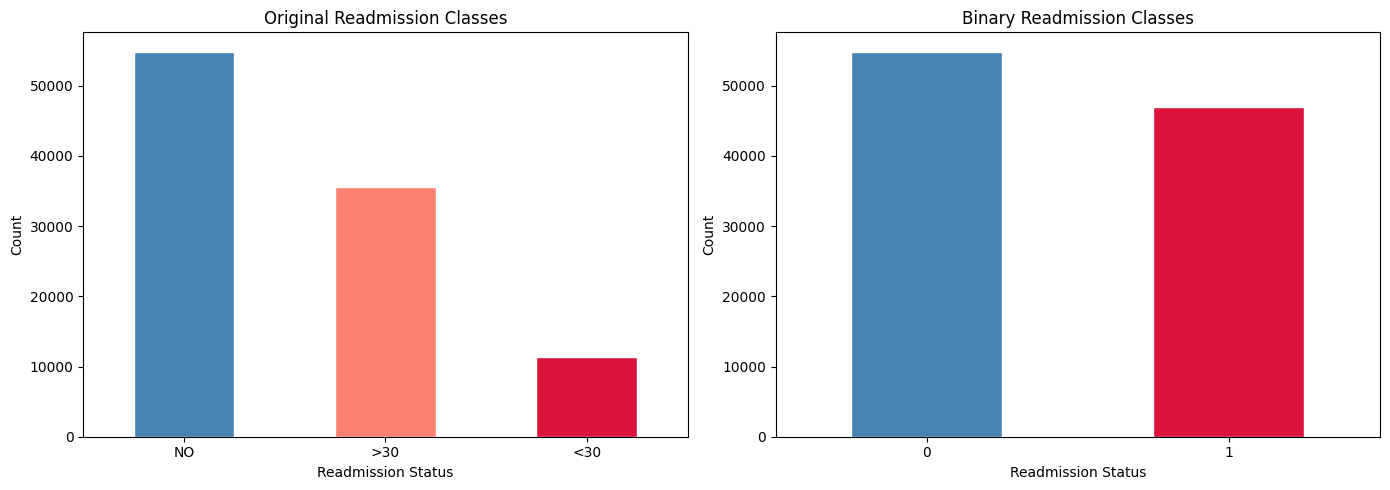

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'crimson'], edgecolor='white'
)
axes[0].set_title('Original Readmission Classes')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['readmitted-binary'].value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'crimson'], edgecolor='white'
)
axes[1].set_title('Binary Readmission Classes')
axes[1].set_xlabel('Readmission Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Note:

Nearly 46% of diabetic patients in this dataset were readmitted after discharge, suggesting that readmission is not a rare edge case but a systemic failure affecting nearly half of all diabetic hospital patients. This framing shifts the problem from anomaly detection to risk stratification; the goal is not to find rare outliers but to distinguish between two comparably sized populations with meaningfully different clinical profiles.

In [ ]:
import numpy as np

df['A1Cresult'] = df['A1Cresult'].fillna("UNK")
df['A1Cresult'].value_counts(normalize=True)

A1Cresult
UNK     0.832773
>8      0.080734
Norm    0.049034
>7      0.037458
Name: count, dtype: float64

In [46]:
result = pd.crosstab(df['A1Cresult'], df['readmitted-binary'])

result['ratio'] = result[1].values / result[0].values

result

readmitted-binary,0,1,ratio
A1Cresult,,,
>7,2129,1683,0.790512
>8,4504,3712,0.824156
Norm,2909,2081,0.715366
UNK,45322,39426,0.869909
